#1. Project Title

Cryptocurrency Volatility Prediction Using Machine Learning

#2. Project Objective

The objective of this project is to build a machine learning model that predicts cryptocurrency volatility using historical market data such as Open, High, Low, Close (OHLC) prices, trading volume, and market capitalization.

Volatility prediction helps traders and financial institutions manage risk, optimize portfolios, and identify unstable market periods.

#3. Dataset Description

Dataset used: Cryptocurrency Historical Prices Dataset

The dataset contains daily records over 50 cryptocurrencies.

Features in Dataset
Feature	Description

1.open-The opening price of the cryptocurrency at the beginning of the trading day.

2.high-The highest price reached by the cryptocurrency during that day.

3.low-The lowest price reached by the cryptocurrency during that day.

4.close-The closing price of the cryptocurrency at the end of the trading day.

5.volume-The total trading volume of the cryptocurrency during the day, representing market activity.

6.marketCap-The total market capitalization of the cryptocurrency, calculated as price × circulating supply.

7.timestamp-Unix timestamp representing the exact time of the recorded data point.

8.crypto_name-The name or symbol of the cryptocurrency (e.g., Bitcoin, Ethereum).

9.date-The calendar date corresponding to the trading data.

In [2]:
#Data Preprocessing Requirements

#Data preprocessing is an important step in machine learning that prepares the raw dataset for analysis and model training. It ensures that the data is clean, consistent, and suitable for building accurate prediction models. The following preprocessing techniques were applied to the cryptocurrency dataset.

#1. Handling Missing Values and Ensuring Data Consistency

#Real-world datasets often contain missing or inconsistent values. These missing values can affect model performance and lead to inaccurate predictions. Therefore, it is necessary to handle them properly.

#In this project, missing values were handled using techniques such as removing incomplete rows or filling missing values using forward filling methods. Additionally, duplicate records were removed and the dataset was sorted based on the date column to maintain chronological order.


import pandas as pd
df=pd.read_csv("dataset.csv")

# Remove missing values
df = df.dropna()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort data by date
df = df.sort_values(by='date')

#This ensures that the dataset remains consistent and suitable for further analysis.



In [3]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.000000e+00,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.000000e+00,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.000000e+00,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.000000e+00,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.000000e+00,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07
...,...,...,...,...,...,...,...,...,...,...
72912,72912,19207.734651,19646.651542,19124.196965,19567.007398,2.212879e+10,3.754443e+11,2022-10-23T23:59:59.999Z,Bitcoin,2022-10-23
72913,72913,1.000066,1.000972,0.999123,1.000572,4.461507e+09,2.164048e+10,2022-10-23T23:59:59.999Z,Binance USD,2022-10-23
72914,72914,0.276523,0.283884,0.273841,0.283243,3.735539e+07,4.236405e+08,2022-10-23T23:59:59.999Z,Basic Attention Token,2022-10-23
72916,72916,8.939706,10.246318,8.930175,9.768685,1.563615e+09,1.269929e+09,2022-10-23T23:59:59.999Z,Aptos,2022-10-23


#2. Normalizing and Scaling Numerical Features

#The dataset contains several numerical features such as open, high, low, close, volume, and marketCap. These features may have very different ranges. For example, market capitalization values are much larger than price values.

#To prevent models from being biased toward larger values, numerical features are normalized using scaling techniques such as Min-Max Scaling.







In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['open','high','low','close','volume','marketCap']] = scaler.fit_transform(
df[['open','high','low','close','volume','marketCap']]
)

#Scaling ensures that all numerical features are brought into a similar range, improving model performance and stability.

In [5]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,0.001671,0.000732,0.001612,0.001715,0.000000,0.001011,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,0.000052,0.000023,0.000050,0.000053,0.000000,0.000049,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,0.001717,0.000769,0.001605,0.001662,0.000000,0.000980,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,0.000053,0.000023,0.000047,0.000050,0.000000,0.000046,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,0.001662,0.000699,0.001470,0.001650,0.000000,0.000973,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07
...,...,...,...,...,...,...,...,...,...,...
72912,72912,0.284350,0.121135,0.287761,0.289595,0.063051,0.294505,2022-10-23T23:59:59.999Z,Bitcoin,2022-10-23
72913,72913,0.000015,0.000006,0.000015,0.000015,0.012712,0.016975,2022-10-23T23:59:59.999Z,Binance USD,2022-10-23
72914,72914,0.000004,0.000002,0.000004,0.000004,0.000106,0.000332,2022-10-23T23:59:59.999Z,Basic Attention Token,2022-10-23
72916,72916,0.000132,0.000063,0.000134,0.000145,0.004455,0.000996,2022-10-23T23:59:59.999Z,Aptos,2022-10-23


In [6]:
#3. Feature Engineering for Volatility and Liquidity Trends

#Feature engineering involves creating new variables from existing features to improve the predictive power of the model.

#In this project, new features related to volatility and liquidity were created.

#Rolling Volatility

#Volatility measures how much the price of a cryptocurrency fluctuates over time.



df['volatility'] = df['close'].rolling(window=7).std()
#Liquidity Ratio

#Liquidity indicates how actively a cryptocurrency is traded and is calculated as the ratio of trading volume to market capitalization.



df['liquidity_ratio'] = df['volume'] / df['marketCap']
#Moving Average

#Moving averages help identify price trends.



df['MA_7'] = df['close'].rolling(window=7).mean()

#These engineered features help capture market behavior and improve the accuracy of volatility prediction models.

In [7]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,volatility,liquidity_ratio,MA_7
0,0,0.001671,0.000732,0.001612,0.001715,0.000000,0.001011,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05,NaN,0.000000,NaN
1,1,0.000052,0.000023,0.000050,0.000053,0.000000,0.000049,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05,NaN,0.000000,NaN
2,2,0.001717,0.000769,0.001605,0.001662,0.000000,0.000980,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06,NaN,0.000000,NaN
3,3,0.000053,0.000023,0.000047,0.000050,0.000000,0.000046,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06,NaN,0.000000,NaN
4,4,0.001662,0.000699,0.001470,0.001650,0.000000,0.000973,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72912,72912,0.284350,0.121135,0.287761,0.289595,0.063051,0.294505,2022-10-23T23:59:59.999Z,Bitcoin,2022-10-23,0.109046,0.214091,0.042324
72913,72913,0.000015,0.000006,0.000015,0.000015,0.012712,0.016975,2022-10-23T23:59:59.999Z,Binance USD,2022-10-23,0.109052,0.748859,0.042311
72914,72914,0.000004,0.000002,0.000004,0.000004,0.000106,0.000332,2022-10-23T23:59:59.999Z,Basic Attention Token,2022-10-23,0.109052,0.320288,0.042311
72916,72916,0.000132,0.000063,0.000134,0.000145,0.004455,0.000996,2022-10-23T23:59:59.999Z,Aptos,2022-10-23,0.109096,4.472348,0.042212


Project Development Steps with Code
#1. Data Collection

The first step is loading the cryptocurrency dataset containing historical market information such as price, trading volume, and market capitalization.



In [8]:

import pandas as pd

# Load dataset
df = pd.read_csv("dataset.csv")

# Display first rows
print(df.head())

# Check dataset information
print(df.info())


   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
--

In [9]:
#2. Data Preprocessing

#Data preprocessing ensures that the dataset is clean and ready for model training.

#Handling Missing Values
# Check missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()
#Convert Date Column
# Convert date column into datetime
df['date'] = pd.to_datetime(df['date'])

# Sort data by date
df = df.sort_values(by='date')
#Normalize Numerical Features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['open','high','low','close','volume','marketCap']] = scaler.fit_transform(
df[['open','high','low','close','volume','marketCap']]
)


Unnamed: 0     0
open           0
high           0
low            0
close          0
volume         0
marketCap      0
timestamp      0
crypto_name    0
date           0
dtype: int64


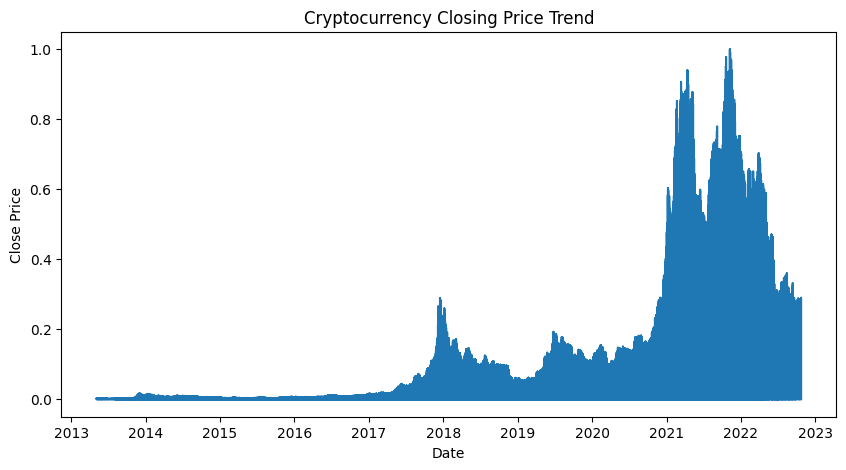

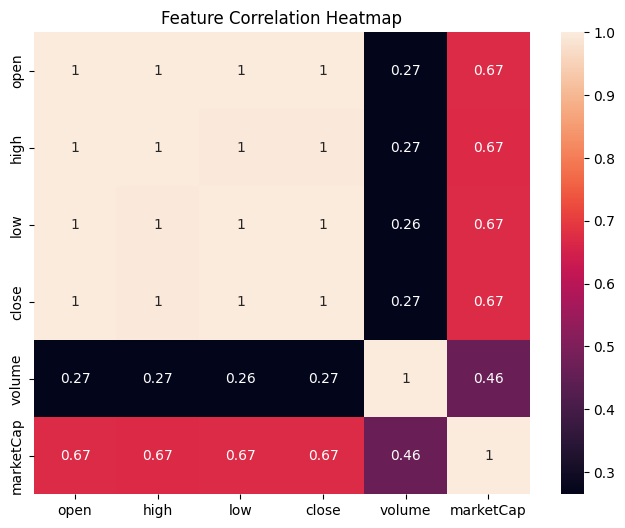

In [11]:
#3. Exploratory Data Analysis (EDA)

#EDA helps identify patterns, trends, and correlations in the dataset.

#Price Trend Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['close'])
plt.title("Cryptocurrency Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()
#Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['open','high','low','close','volume','marketCap']].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [12]:
#4. Feature Engineering

#New features are created to capture volatility and liquidity trends.

#Moving Average
df['MA_7'] = df['close'].rolling(window=7).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()
#Rolling Volatility
df['volatility'] = df['close'].rolling(window=7).std()
#Liquidity Ratio
df['liquidity_ratio'] = df['volume'] / df['marketCap']
#Bollinger Bands
df['upper_band'] = df['MA_7'] + (2 * df['volatility'])
df['lower_band'] = df['MA_7'] - (2 * df['volatility'])
#Average True Range (ATR)
df['ATR'] = df['high'] - df['low']


In [14]:
df

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,MA_7,MA_30,volatility,liquidity_ratio,upper_band,lower_band,ATR
0,0,0.001671,0.000732,0.001612,0.001715,0.000000,0.001011,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000880
1,1,0.000052,0.000023,0.000050,0.000053,0.000000,0.000049,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000028
2,2,0.001717,0.000769,0.001605,0.001662,0.000000,0.000980,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000836
3,3,0.000053,0.000023,0.000047,0.000050,0.000000,0.000046,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000024
4,4,0.001662,0.000699,0.001470,0.001650,0.000000,0.000973,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72912,72912,0.284350,0.121135,0.287761,0.289595,0.063051,0.294505,2022-10-23T23:59:59.999Z,Bitcoin,2022-10-23,0.042324,0.019603,0.109046,0.214091,0.260416,-0.175768,-0.166626
72913,72913,0.000015,0.000006,0.000015,0.000015,0.012712,0.016975,2022-10-23T23:59:59.999Z,Binance USD,2022-10-23,0.042311,0.019604,0.109052,0.748859,0.260415,-0.175793,-0.000009
72914,72914,0.000004,0.000002,0.000004,0.000004,0.000106,0.000332,2022-10-23T23:59:59.999Z,Basic Attention Token,2022-10-23,0.042311,0.019603,0.109052,0.320288,0.260415,-0.175792,-0.000002
72916,72916,0.000132,0.000063,0.000134,0.000145,0.004455,0.000996,2022-10-23T23:59:59.999Z,Aptos,2022-10-23,0.042212,0.019608,0.109096,4.472348,0.260404,-0.175980,-0.000071


#5. Model Selection

Machine learning models suitable for volatility prediction include:

#Linear Regression

#Random Forest

#Gradient Boosting

#LSTM (for time-series)

In this project we use Random Forest Regression.

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Remove infinity values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows with NaN values
df = df.dropna()

# Select Features
X = df[['open','high','low','close','volume','marketCap','MA_7','MA_30','liquidity_ratio','ATR']]

# Target Variable
y = df['volatility']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully")

/tmp/ipykernel_310/4264009236.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace([np.inf, -np.inf], np.nan, inplace=True)


Model training completed successfully


In [22]:
#7. Model Evaluation

#After training, we evaluate the model using RMSE, MAE, and R² score.

#Prediction
y_pred = model.predict(X_test)
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
#MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
#R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 0.004405239755461041
MAE: 0.0011281470848408621
R2 Score: 0.996124827591584


In [31]:
#Model Optimization and Deployment

#1. Hyperparameter Tuning

#Hyperparameter tuning is used to improve the performance of the machine learning model by selecting the best combination of parameters. In this project, Random Forest Regression is optimized using GridSearchCV to find the best values for parameters such as the number of trees and tree depth.

#Code
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor





In [42]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='r2')

In [46]:
# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

#This step helps improve prediction accuracy by selecting the optimal model configuration.

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 150}


In [47]:
#2. Model Testing and Validation

#After tuning the model, it is tested using unseen test data to evaluate its performance. The model predictions are compared with actual values using evaluation metrics such as RMSE, MAE, and R² score.

#Code
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

#These metrics help measure how accurately the model predicts cryptocurrency volatility.



RMSE: 0.004400440442565372
MAE: 0.001155322839619325
R2 Score: 0.9961332666482563


In [48]:
#3. Local Deployment

#Once the model is trained and validated, it can be deployed locally so users can input new data and get volatility predictions. This can be done using Streamlit or Flask.

#Streamlit Deployment (Recommended)

#Streamlit provides an easy way to build interactive web applications for machine learning models.


import joblib

joblib.dump(best_model, "crypto_volatility_model.pkl")
#Streamlit App Code
import streamlit as st
import joblib
import numpy as np

# Load trained model
model = joblib.load("crypto_volatility_model.pkl")

st.title("Cryptocurrency Volatility Predictor")

open_price = st.number_input("Open Price")
high_price = st.number_input("High Price")
low_price = st.number_input("Low Price")
close_price = st.number_input("Close Price")
volume = st.number_input("Volume")
marketCap = st.number_input("Market Cap")

if st.button("Predict Volatility"):

    features = np.array([[open_price, high_price, low_price, close_price, volume, marketCap]])

    prediction = model.predict(features)

    st.success(f"Predicted Volatility: {prediction[0]}")

2026-03-06 16:37:58.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 16:37:58.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar